# Cheat Sheet: Z-Tests and Statistical Power in Python

A fast, scannable reference for the formulas and code idioms used across this lab bundle. Run the
imports cell once, then jump to whichever section you need — every cell is self-contained (aside
from the shared imports) so you can copy-paste snippets directly into your own project.

In [1]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import math

from statsmodels.stats.weightstats import ztest
from statsmodels.stats.proportion import proportions_ztest, proportion_effectsize
from statsmodels.stats.power import (
    TTestPower, TTestIndPower, NormalIndPower,
    GofChisquarePower, FTestPower, FTestAnovaPower
)
from statsmodels.stats.gof import chisquare_effectsize


## 1. Which test do I use?

| Question you're asking | Test | Key inputs |
|---|---|---|
| Is this population mean different from a value, and is σ known? | One-sample z-test | x̄, μ0, σ, n |
| Is this population mean different from a value, and σ is *unknown*? | One-sample t-test | x̄, μ0, s, n |
| Do two independent population means differ, σ known? | Two-sample z-test | x̄1, x̄2, σ1, σ2, n1, n2 |
| Do two independent population means differ, σ unknown? | Two-sample t-test | x̄1, x̄2, s1, s2, n1, n2 |
| Does a population proportion differ from a value? | One-proportion z-test | p̂, p0, n |
| Do two population proportions differ? | Two-proportion z-test | p̂1, p̂2, n1, n2 |
| Do observed category counts match hypothesized proportions? | Chi-square goodness-of-fit | observed counts, expected proportions |
| Do 3+ group means differ? | ANOVA (F-test) | group means, stds, ns |
| Do two variances differ? | F-test | s1², s2², df1, df2 |

**Rule of thumb:** if you don't independently know the population standard deviation, default to
a **t-test**, not a z-test. The z-test scenarios in this lab assume σ is known because it's given
in the problem — real data almost never hands you that for free.

## 2. Z-score and z-statistic

| Formula | Code |
|---|---|
| z = (x − x̄) / σ | `stats.zscore(array)` or `(x - mean) / std` |
| z for a sample mean: z = (x̄ − μ) / (σ/√n) | manual: `(xbar - mu) / (sigma / math.sqrt(n))` |

In [2]:
# z-scores for an array of raw values
values = np.array([90, 78, 110, 110, 99, 115, 130, 100, 95, 93])
z = stats.zscore(values)   # uses the SAMPLE mean/std of `values` itself
print(z)

# z-statistic for a sample mean vs. a hypothesized population mean (sigma known)
xbar, mu, sigma, n = 104.17, 98, 12, 30
z_stat = (xbar - mu) / (sigma / math.sqrt(n))
print(z_stat)

[-0.86066297 -1.72132593  0.57377531  0.57377531 -0.21516574  0.93238488
  2.00821359 -0.14344383 -0.5020534  -0.64549722]
2.81620681650573


## 3. p-values and critical values

| Task | Code |
|---|---|
| p-value, left-tailed | `stats.norm.sf(abs(z))`  (equivalently `stats.norm.cdf(z)` if z<0) |
| p-value, right-tailed | `stats.norm.sf(z)` |
| p-value, two-tailed | `stats.norm.sf(abs(z)) * 2` |
| Critical value, left-tailed | `stats.norm.ppf(alpha)` |
| Critical value, right-tailed | `stats.norm.ppf(1 - alpha)` |
| Critical values, two-tailed | `stats.norm.ppf(alpha/2)`  and  `stats.norm.ppf(1 - alpha/2)` |

In [3]:
alpha = 0.05
z_example = 2.67

p_left = stats.norm.sf(abs(-z_example))
p_right = stats.norm.sf(z_example)
p_two = stats.norm.sf(abs(z_example)) * 2

crit_left = stats.norm.ppf(alpha)
crit_right = stats.norm.ppf(1 - alpha)
crit_two = (stats.norm.ppf(alpha/2), stats.norm.ppf(1 - alpha/2))

print("p-values:", p_left, p_right, p_two)
print("critical values:", crit_left, crit_right, crit_two)

p-values: 0.0037925623476854887 0.0037925623476854887 0.007585124695370977
critical values: -1.6448536269514729 1.6448536269514722 (np.float64(-1.9599639845400545), np.float64(1.959963984540054))


## 4. One-sample and two-sample z-tests for means

`statsmodels.stats.weightstats.ztest(x1, x2=None, value=0, alternative='two-sided')`

- `alternative='two-sided'` (default), `'larger'` (right-tailed), or `'smaller'` (left-tailed)
- One-sample: pass only `x1`, set `value` = hypothesized mean
- Two-sample: pass `x1` and `x2`, `value` = hypothesized difference (usually 0)

In [4]:
sample = [95, 110, 105, 120, 125, 110, 98, 90, 99, 100,
          110, 112, 106, 92, 108, 97, 95, 99, 100, 100,
          103, 125, 122, 110, 112, 102, 92, 97, 89, 102]

# One-sample, right-tailed: H0: mu <= 98, Ha: mu > 98
z_stat, p_val = ztest(sample, value=98, alternative='larger')
print(z_stat, p_val)

# Two-sample, two-tailed: H0: mu1 = mu2
sample_b = [98, 90, 100, 93, 91, 79, 90, 100, 121, 89,
            101, 98, 75, 90, 95, 99, 100, 120, 121, 95,
            96, 89, 115, 99, 95, 121, 122, 98, 97, 97]
z_stat2, p_val2 = ztest(sample, sample_b, value=0, alternative='two-sided')
print(z_stat2, p_val2)

3.397499328379722 0.00034002377451735716
1.7572688143960962 0.07887200072419194


## 5. Manual z-formulas for means (when you only have summary stats, not raw data)

| Test | Formula |
|---|---|
| One-sample | z = (x̄ − μ0) / (σ/√n) |
| Two-sample | z = (x̄1 − x̄2 − Ω) / √(σ1²/n1 + σ2²/n2) |

In [5]:
# One-sample from summary stats
xbar, mu0, sigma, n = 104.17, 98, 12, 30
z_one = (xbar - mu0) / (sigma / math.sqrt(n))

# Two-sample from summary stats (Omega = hypothesized difference, usually 0)
xbar1, xbar2, sigma1, sigma2, n1, n2, Omega = 104.2, 96.9, 11.5, 12.8, 30, 30, 0
z_two = (xbar1 - xbar2 - Omega) / math.sqrt(sigma1**2/n1 + sigma2**2/n2)

print(z_one, z_two)

2.81620681650573 2.323654839390854


## 6. Z-tests for proportions

`statsmodels.stats.proportion.proportions_ztest(count, nobs, value=None, alternative='two-sided')`

- One-proportion: `count` and `nobs` are scalars; `value` = hypothesized proportion p0
- Two-proportion: `count` and `nobs` are 2-element lists `[count1, count2]`, `[nobs1, nobs2]`;
  omit `value` (defaults to testing p1 = p2)

In [6]:
# One-proportion
z_p, p_val_p = proportions_ztest(count=0.8*500, nobs=500, value=0.84, alternative='two-sided')
print(z_p, p_val_p)

# Two-proportion
z_2p, p_val_2p = proportions_ztest([92, 78], [620, 590], alternative='two-sided')
print(z_2p, p_val_2p)

-2.236067977499786 0.0253473186774685
0.8097508470328323 0.41808338781904497


## 7. Manual two-proportion z-formula

  p̄ = (n1·p̂1 + n2·p̂2) / (n1 + n2)          (pooled proportion)

  z = (p̂1 − p̂2) / √( p̄(1−p̄)(1/n1 + 1/n2) )

In [7]:
p1_hat, p2_hat, n1, n2 = 0.8, 0.7, 100.0, 100.0
p_pool = (p1_hat*n1 + p2_hat*n2) / (n1 + n2)
z_manual = (p1_hat - p2_hat) / math.sqrt(p_pool*(1-p_pool)*(1/n1 + 1/n2))
p_val_manual = stats.norm.sf(abs(z_manual)) * 2
print(p_pool, z_manual, p_val_manual)

0.75 1.6329931618554536 0.1024704348597491


## 8. Confidence intervals

| Parameter | Formula |
|---|---|
| Mean (σ known) | x̄ ± z_(α/2) · (σ/√n) |
| Proportion | p̂ ± z_(α/2) · √(p̂(1−p̂)/n) |

In [8]:
def ci_mean(xbar, sigma, n, confidence=0.95):
    z_crit = stats.norm.ppf(1 - (1-confidence)/2)
    margin = z_crit * (sigma / math.sqrt(n))
    return xbar - margin, xbar + margin

def ci_proportion(p_hat, n, confidence=0.95):
    z_crit = stats.norm.ppf(1 - (1-confidence)/2)
    margin = z_crit * math.sqrt(p_hat*(1-p_hat)/n)
    return p_hat - margin, p_hat + margin

print(ci_mean(104.17, 12, 30))
print(ci_proportion(0.16, 500))

(np.float64(99.87593405507883), np.float64(108.46406594492117))
(np.float64(0.1278661528757825), np.float64(0.1921338471242175))


## 9. Effect sizes

| Effect size | Formula | Helper |
|---|---|---|
| Cohen's d (two means) | \|μ1 − μ2\| / σ_pooled | manual, see below |
| Cohen's h (two proportions) | via arcsine transform | `proportion_effectsize(p1, p2)` |
| Cohen's w (chi-square) | via category proportions | `chisquare_effectsize(probs0, probs1, cohen=True)` |
| Pooled SD | √[(n1σ1² + n2σ2²) / (n1+n2)]  *(population-style, no −1)* or with (n−1) terms for sample-style |

In [9]:
def pooled_sd(std1, n1, std2, n2, sample_style=True):
    if sample_style:
        return math.sqrt(((n1-1)*std1**2 + (n2-1)*std2**2) / (n1 + n2 - 2))
    else:
        return math.sqrt((n1*std1**2 + n2*std2**2) / (n1 + n2))

def cohens_d(mean1, std1, n1, mean2, std2, n2):
    return abs(mean1 - mean2) / pooled_sd(std1, n1, std2, n2)

print(cohens_d(14, 2, 50, 16, 2.6, 30))
print(proportion_effectsize(0.10, 0.08))
print(chisquare_effectsize(probs0=[1/3, 1/3, 1/3], probs1=[0.25, 0.45, 0.30], cohen=True))

0.892097057204833
0.0699880043701876
0.25495097567963926


## 10. Power analysis quick reference

Every `solve_power()` call takes all-but-one of `{effect_size, nobs, alpha, power}` (plus
test-specific args) and solves for whichever one is `None`.

| Test family | Class | Notes |
|---|---|---|
| One-sample t-test | `TTestPower()` | `nobs` = single sample size |
| Two-sample t-test (independent) | `TTestIndPower()` | `nobs1`, `ratio` = n2/n1 |
| Two-sample z-test (pooled, sigma known) | `NormalIndPower()` | same args as `TTestIndPower` |
| Chi-square goodness-of-fit | `GofChisquarePower()` | needs `n_bins` |
| F-test (two variances) | `FTestPower()` | needs `df_num`, `df_denom` |
| ANOVA F-test (k groups) | `FTestAnovaPower()` | needs `k_groups` |

In [10]:
# Solve for POWER given n, alpha, effect size
power_val = TTestIndPower().solve_power(effect_size=0.5, nobs1=30, ratio=1.0, alpha=0.05)
print("achieved power:", power_val)

# Solve for REQUIRED N given desired power, alpha, effect size
required_n = TTestIndPower().solve_power(effect_size=0.5, power=0.8, ratio=1.0, alpha=0.05)
print("required n per group:", math.ceil(required_n))

# Chi-square example
chi_power = GofChisquarePower().solve_power(effect_size=0.2, nobs=150, alpha=0.05, n_bins=3)
print("chi-square achieved power:", chi_power)

# ANOVA example
anova_n = FTestAnovaPower().solve_power(effect_size=0.3, power=0.8, alpha=0.05, k_groups=3)
print("ANOVA required n per group:", math.ceil(anova_n))

achieved power: 0.4778965207601643
required n per group: 64
chi-square achieved power: 0.5840400973870823
ANOVA required n per group: 111


## 11. Plotting a power curve

`solve_power`-based classes have a built-in `.plot_power()`, or build your own with a list
comprehension for full control over styling.

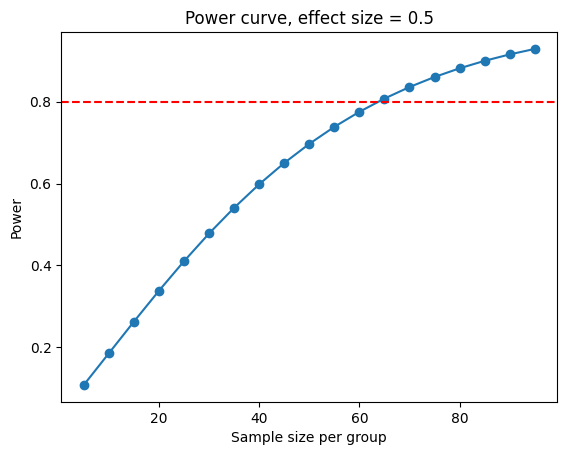

In [11]:
import matplotlib.pyplot as plt

nobs_range = np.arange(5, 100, 5)
power_curve = [TTestIndPower().solve_power(effect_size=0.5, nobs1=n, ratio=1.0, alpha=0.05)
               for n in nobs_range]

plt.plot(nobs_range, power_curve, marker='o')
plt.axhline(0.8, color='red', linestyle='--')
plt.xlabel('Sample size per group')
plt.ylabel('Power')
plt.title('Power curve, effect size = 0.5')
plt.show()

## 12. Monte Carlo power (for non-normal data)

When data isn't normal, simulate instead of relying on the closed-form formula:

```python
def monte_carlo_power(n, true_diff, distribution, alpha=0.05, n_sim=2000, seed=0):
    rng = np.random.default_rng(seed)
    rejections = 0
    for _ in range(n_sim):
        if distribution == 'normal':
            g1 = rng.normal(0, 1, n); g2 = rng.normal(true_diff, 1, n)
        elif distribution == 'exponential':
            g1 = rng.exponential(1, n); g2 = rng.exponential(1, n) + true_diff
        _, p = stats.ttest_ind(g1, g2)
        rejections += (p <= alpha)
    return rejections / n_sim
```

Use this pattern whenever: data is skewed, bounded, count-based, or you have a nonstandard test
statistic that doesn't have a ready-made `statsmodels` power class.

## 13. Common pitfalls checklist

- [ ] Did you check whether σ is genuinely known, or should this be a **t-test**?
- [ ] Two-tailed test: did you use `abs()` and multiply/split by 2 where appropriate?
- [ ] Two-sample test: are the samples truly **independent** (not paired/matched)?
- [ ] Power analysis: is your assumed effect size defensible, not just convenient?
- [ ] Power analysis: is your data plausibly normal? If not, consider a Monte Carlo approach.
- [ ] Are you running many tests at once? Consider a multiple-comparisons correction — none of
      the tests here apply one automatically.
- [ ] Confidence interval vs. hypothesis test: for a two-sided test at level α, rejecting
      H0: parameter = v is equivalent to v falling outside the (1−α) CI. Use this as a sanity check.
- [ ] "Fail to reject H0" is not proof H0 is true — it just means you lack evidence against it,
      possibly due to low power.
